In [1]:
# MELA Project - Step 1: Orientation Standardization


#The original MELA CT volumes are not stored in canonical RAS orientation.
#Therefore, each NIfTI volume is converted to canonical orientation using `nibabel.as_closest_canonical()` before any visualization, bounding box transformation, or pseudo-mask generation.

#This ensures that all downstream processing steps operate in a consistent coordinate system.

In [2]:
import os

BASE = "/content/drive/MyDrive/MELA"
TRAIN_DIR = os.path.join(BASE, "images", "train")
VAL_DIR = os.path.join(BASE, "images", "val")
ANN_DIR = os.path.join(BASE, "annotations")

print("BASE:", BASE)
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("ANN_DIR:", ANN_DIR)

BASE: /content/drive/MyDrive/MELA
TRAIN_DIR: /content/drive/MyDrive/MELA/images/train
VAL_DIR: /content/drive/MyDrive/MELA/images/val
ANN_DIR: /content/drive/MyDrive/MELA/annotations


In [3]:
!pip install nibabel pandas matplotlib -q

In [4]:
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

In [5]:
train_files = sorted([f for f in os.listdir(TRAIN_DIR) if f.endswith(".nii.gz")])
val_files = sorted([f for f in os.listdir(VAL_DIR) if f.endswith(".nii.gz")])

print("Train dosya sayısı:", len(train_files))
print("Val dosya sayısı:", len(val_files))
print("İlk 5 train dosyası:", train_files[:5])
print("İlk 5 val dosyası:", val_files[:5])

Train dosya sayısı: 260
Val dosya sayısı: 110
İlk 5 train dosyası: ['mela_0001.nii.gz', 'mela_0002.nii.gz', 'mela_0003.nii.gz', 'mela_0004.nii.gz', 'mela_0005.nii.gz']
İlk 5 val dosyası: ['mela_0771.nii.gz', 'mela_0772.nii.gz', 'mela_0773.nii.gz', 'mela_0774.nii.gz', 'mela_0775.nii.gz']


In [7]:
sample_file = train_files[0]
sample_id = sample_file.replace(".nii.gz", "")
sample_path = os.path.join(TRAIN_DIR, sample_file)

print("Örnek dosya:", sample_file)
print("Örnek ID:", sample_id)
print("Dosya yolu:", sample_path)

Örnek dosya: mela_0001.nii.gz
Örnek ID: mela_0001
Dosya yolu: /content/drive/MyDrive/MELA/images/train/mela_0001.nii.gz


In [8]:
img = nib.load(sample_path)
img_data = img.get_fdata()

print("Shape:", img_data.shape)
print("Voxel spacing:", img.header.get_zooms())
print("Affine matrix:\n", img.affine)

Shape: (512, 512, 385)
Voxel spacing: (np.float32(0.60546875), np.float32(0.60546875), np.float32(1.0))
Affine matrix:
 [[  -0.60546875    0.            0.          162.13000488]
 [   0.           -0.60546875    0.          -15.69999981]
 [   0.            0.            1.         -394.97000122]
 [   0.            0.            0.            1.        ]]


In [10]:
print("Original axis codes:", nib.aff2axcodes(img.affine))

Original axis codes: ('L', 'P', 'S')


In [13]:
img_canon = nib.as_closest_canonical(img)
img_data_canon = img_canon.get_fdata()

print("Canonical shape:", img_data_canon.shape)
print("Canonical axis codes:", nib.aff2axcodes(img_canon.affine))
print("Canonical affine:\n", img_canon.affine)

Canonical shape: (512, 512, 385)
Canonical axis codes: ('R', 'A', 'S')
Canonical affine:
 [[   0.60546875    0.            0.         -147.26452637]
 [   0.            0.60546875    0.         -325.09453106]
 [   0.            0.            1.         -394.97000122]
 [   0.            0.            0.            1.        ]]


In [16]:
print("Original axis codes :", nib.aff2axcodes(img.affine))
print("Canonical axis codes:", nib.aff2axcodes(img_canon.affine))

Original axis codes : ('L', 'P', 'S')
Canonical axis codes: ('R', 'A', 'S')


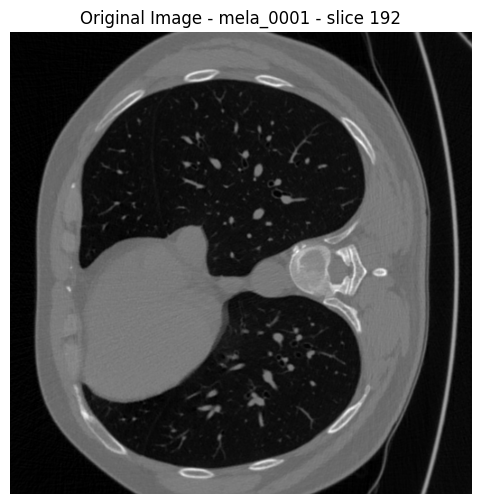

In [18]:
z_raw = img_data.shape[2] // 2

plt.figure(figsize=(6,6))
plt.imshow(img_data[:, :, z_raw], cmap="gray")
plt.title(f"Original Image - {sample_id} - slice {z_raw}")
plt.axis("off")
plt.show()

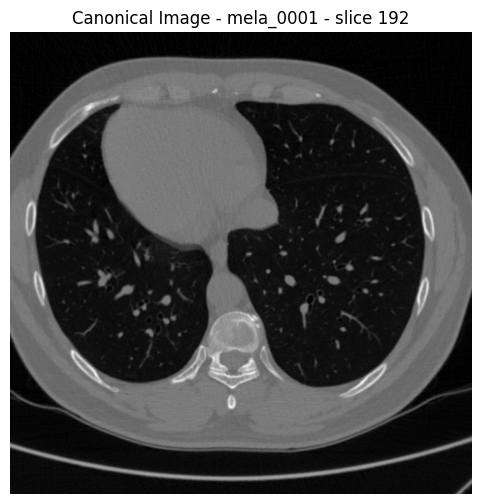

In [19]:
z_canon = img_data_canon.shape[2] // 2

plt.figure(figsize=(6,6))
plt.imshow(img_data_canon[:, :, z_canon].T, cmap="gray", origin="lower")
plt.title(f"Canonical Image - {sample_id} - slice {z_canon}")
plt.axis("off")
plt.show()

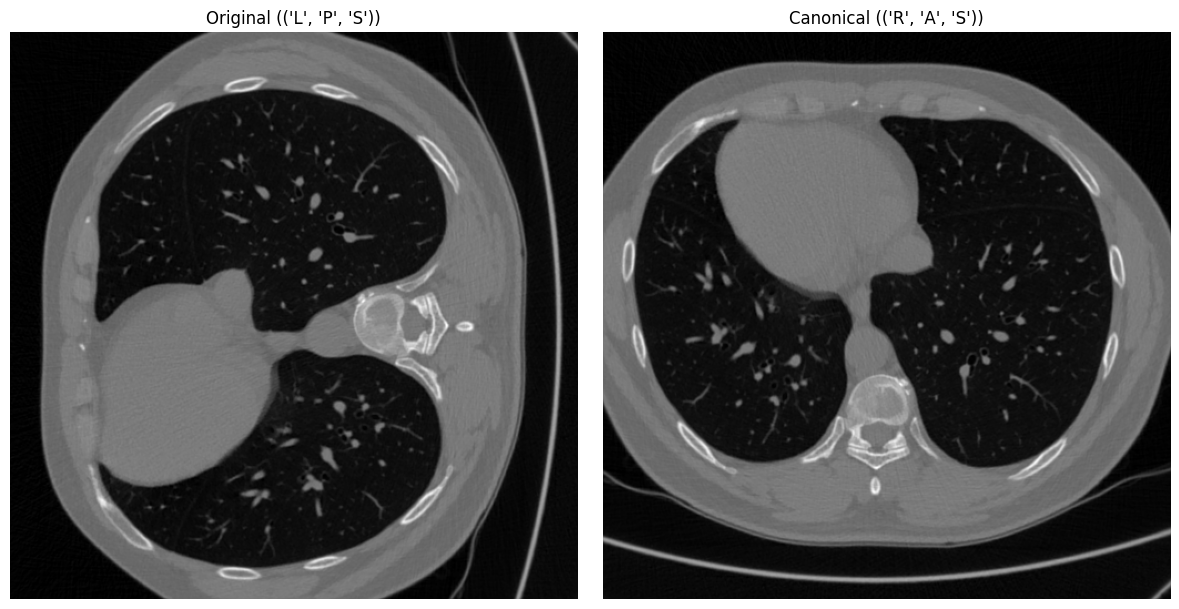

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_data[:, :, z_raw], cmap="gray")
axes[0].set_title(f"Original ({nib.aff2axcodes(img.affine)})")
axes[0].axis("off")

axes[1].imshow(img_data_canon[:, :, z_canon].T, cmap="gray", origin="lower")
axes[1].set_title(f"Canonical ({nib.aff2axcodes(img_canon.affine)})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [22]:
def load_canonical_nifti(nifti_path):
    """
    NIfTI dosyasını yükler, canonical orientation'a çevirir
    ve hem orijinal hem canonical objeleri döndürür.
    """
    img = nib.load(nifti_path)
    img_canon = nib.as_closest_canonical(img)

    img_data = img.get_fdata()
    img_data_canon = img_canon.get_fdata()

    return img, img_data, img_canon, img_data_canon

In [23]:
img, img_data, img_canon, img_data_canon = load_canonical_nifti(sample_path)

print("Original axis codes :", nib.aff2axcodes(img.affine))
print("Canonical axis codes:", nib.aff2axcodes(img_canon.affine))
print("Original shape:", img_data.shape)
print("Canonical shape:", img_data_canon.shape)

Original axis codes : ('L', 'P', 'S')
Canonical axis codes: ('R', 'A', 'S')
Original shape: (512, 512, 385)
Canonical shape: (512, 512, 385)


In [24]:
def show_orientation_comparison(img_data, img, img_data_canon, img_canon, sample_id="sample"):
    z_raw = img_data.shape[2] // 2
    z_canon = img_data_canon.shape[2] // 2

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(img_data[:, :, z_raw], cmap="gray")
    axes[0].set_title(f"Original {sample_id}\n{nib.aff2axcodes(img.affine)}")
    axes[0].axis("off")

    axes[1].imshow(img_data_canon[:, :, z_canon].T, cmap="gray", origin="lower")
    axes[1].set_title(f"Canonical {sample_id}\n{nib.aff2axcodes(img_canon.affine)}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

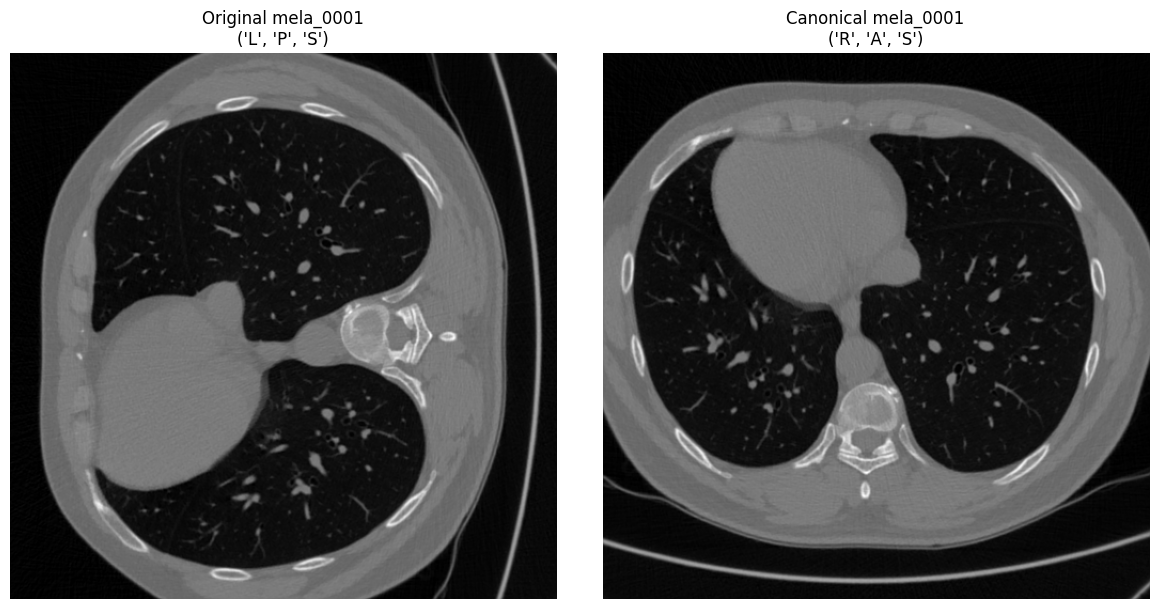

In [25]:
show_orientation_comparison(img_data, img, img_data_canon, img_canon, sample_id)